# 03 Preprocessing Verification

This notebook verifies the preprocessing pipeline and ensures that data splits (train/val/test) maintain consistent distributions.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys
from sklearn.pipeline import Pipeline
from pathlib import Path

# Add src to path
sys.path.append('..')
from src.preprocessing import load_and_split_data, get_preprocessing_pipeline

# Styling: Economist-inspired minimal style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'font.family': 'sans-serif',
    'axes.titleweight': 'bold',
    'axes.titlesize': 14,
    'axes.labelcolor': '#333333',
    'axes.edgecolor': '#cccccc',
    'grid.color': '#eeeeee',
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.figsize': (10, 6)
})
COLORS = ['#475ED1', '#E3120B'] # Economist blue/red

# Project root = parent of the notebooks folder
PROJECT_ROOT = Path.cwd().resolve().parent  # assumes notebook is run from /notebooks

def save_and_show(fig_name: str):
    figures_dir = PROJECT_ROOT / "outputs" / "figures"
    figures_dir.mkdir(parents=True, exist_ok=True)

    plt.savefig(figures_dir / f"{fig_name}.png", dpi=300, bbox_inches="tight")
    plt.show()

DATA_PATH = "../data/processed/adult_cleaned.csv"
print("Setup complete.")

Setup complete.


## 1. Load and Split Data

We perform a stratified split to ensure consistent target distribution across sets.

In [2]:
df_train, df_val, df_test = load_and_split_data(
    DATA_PATH,
    target_col="income",
    test_size=0.1,
    val_size=0.1,
    random_state=42
)

print(f"Splits created:")
print(f"Train: {df_train.shape}")
print(f"Val:   {df_val.shape}")
print(f"Test:  {df_test.shape}")

Splits created:
Train: (39073, 14)
Val:   (4884, 14)
Test:  (4885, 14)


## 2. Fit and Transform Pipeline

We fit the preprocessing pipeline on the training set ONLY to avoid data leakage.

In [3]:
num_cols = ['age', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
cat_cols = ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']

preprocessor = get_preprocessing_pipeline(num_cols, cat_cols, scale=True)

X_train = df_train.drop('income', axis=1)
X_val = df_val.drop('income', axis=1)
X_test = df_test.drop('income', axis=1)

# Fit on train, transform all
X_train_proc = preprocessor.fit_transform(X_train)
X_val_proc = preprocessor.transform(X_val)
X_test_proc = preprocessor.transform(X_test)

print(f"Preprocessing complete.")
print(f"Processed Train shape: {X_train_proc.shape}")
print(f"Processed Val shape:   {X_val_proc.shape}")
print(f"Processed Test shape:  {X_test_proc.shape}")

Preprocessing complete.
Processed Train shape: (39073, 67)
Processed Val shape:   (4884, 67)
Processed Test shape:  (4885, 67)


## 3. Verification Stats

Ensure no missing values and consistent feature counts.

In [4]:
def verify_processed(X, name):
    n_nans = np.isnan(X).sum()
    print(f"--- {name} Verification ---")
    print(f"Missing values: {n_nans}")
    print(f"Feature count: {X.shape[1]}")

verify_processed(X_train_proc, "Train")
verify_processed(X_val_proc, "Val")
verify_processed(X_test_proc, "Test")

print("Class Balance Across Splits:")
print(f"Train >50K: {df_train['income'].value_counts(normalize=True)['>50K']:.4f}")
print(f"Val >50K:   {df_val['income'].value_counts(normalize=True)['>50K']:.4f}")
print(f"Test >50K:  {df_test['income'].value_counts(normalize=True)['>50K']:.4f}")

--- Train Verification ---
Missing values: 0
Feature count: 67
--- Val Verification ---
Missing values: 0
Feature count: 67
--- Test Verification ---
Missing values: 0
Feature count: 67
Class Balance Across Splits:
Train >50K: 0.2393
Val >50K:   0.2394
Test >50K:  0.2393


## 4. Split Verification Visualization

We verify that the income distribution and age distribution remain consistent across splits.

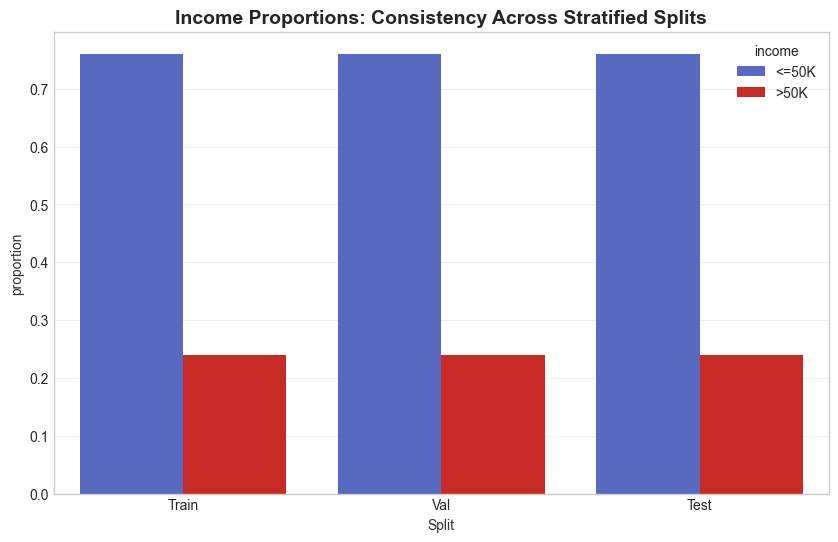

In [7]:
# Plot 1: Income Proportions Across Splits
splits_list = []
for name, df in zip(['Train', 'Val', 'Test'], [df_train, df_val, df_test]):
    prop = df['income'].value_counts(normalize=True).reset_index()
    prop.columns = ['income', 'proportion']
    prop['Split'] = name
    splits_list.append(prop)

df_plots = pd.concat(splits_list)

plt.figure(figsize=(10, 6))
sns.barplot(data=df_plots, x='Split', y='proportion', hue='income', palette=COLORS)
plt.title("Income Proportions: Consistency Across Stratified Splits")
save_and_show("preprocessing_income_proportions")

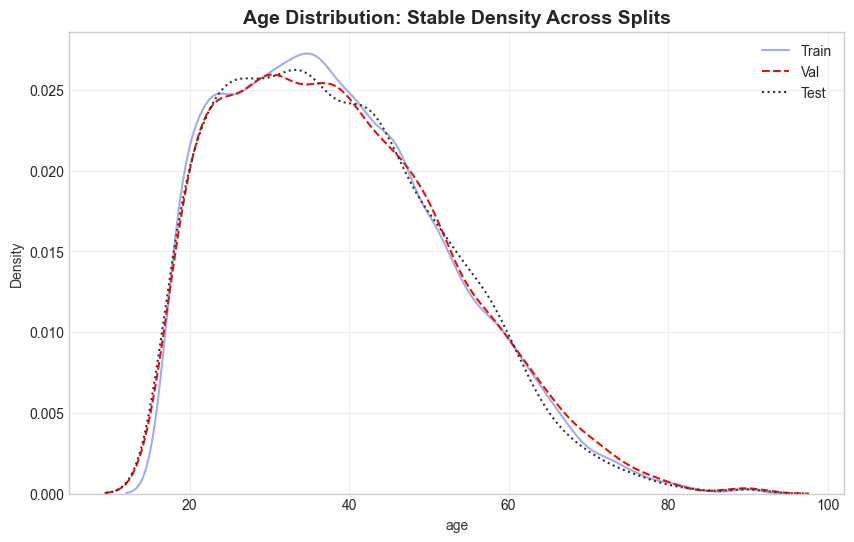

In [8]:
# Plot 2: Age Distribution Overlay
plt.figure(figsize=(10, 6))
sns.kdeplot(df_train['age'], label='Train', color='#475ED1', alpha=0.5)
sns.kdeplot(df_val['age'], label='Val', color='#E3120B', ls='--')
sns.kdeplot(df_test['age'], label='Test', color='#333333', ls=':')
plt.title("Age Distribution: Stable Density Across Splits")
plt.legend()
save_and_show("preprocessing_age_distribution")